In [1]:

import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from collections import defaultdict
import time

# Set random seed for reproducibility
np.random.seed(42)

# Load the omega values (pre-computed for N=10^6)
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_values = pickle.load(f)

print(f"Loaded omega values for n=1 to {len(omega_values)}")
print(f"Omega values shape: {omega_values.shape}")
print(f"Sample omega values (n=1 to 10): {omega_values[:10]}")


Loaded omega values for n=1 to 1000000
Omega values shape: (1000000,)
Sample omega values (n=1 to 10): [0 1 1 2 1 2 1 3 2 2]


In [2]:

def kahan_sum_complex(values):
 """
 Kahan compensated summation for complex arrays.
 Critical for numerical precision in Dirichlet sums.
 """
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 return s

def compute_dirichlet_zeta(t, N, omega_vals):
 """
 Compute D_zeta(t; N) = Σ_{n=1}^N 1/n^{1/2+it}
 
 Parameters:
 -----------
 t : float
 The imaginary parameter
 N : int
 Truncation limit
 omega_vals : array
 Omega values for n=1 to N (for decomposition)
 
 Returns:
 --------
 D_total : complex
 The total Dirichlet sum
 """
 n = np.arange(1, N+1)
 # Compute 1/n^{1/2+it} = 1/sqrt(n) * exp(-it*log(n))
 coeffs = 1.0 / np.sqrt(n) * np.exp(-1j * t * np.log(n))
 D_total = kahan_sum_complex(coeffs)
 return D_total

def compute_omega_class_sums(t, N, omega_vals, max_k=10):
 """
 Compute the omega-class decomposition S_k for k=1 to max_k.
 S_k = Σ_{n: Ω(n)=k} a_n/n^{1/2+it}
 For zeta function, a_n = 1 for all n.
 
 Parameters:
 -----------
 t : float
 The imaginary parameter
 N : int
 Truncation limit
 omega_vals : array
 Array of Ω(n) values for n=1 to N
 max_k : int
 Maximum omega class to compute
 
 Returns:
 --------
 S_dict : dict
 Dictionary with keys k=1 to max_k and values S_k (complex)
 """
 S_dict = {}
 
 for k in range(1, max_k + 1):
 # Find indices where Ω(n) = k (remembering n starts at 1, but array index at 0)
 mask = (omega_vals[:N] == k)
 indices = np.where(mask)[0]
 
 if len(indices) > 0:
 # n values are indices + 1
 n_vals = indices + 1
 # Compute coefficients
 coeffs = 1.0 / np.sqrt(n_vals) * np.exp(-1j * t * np.log(n_vals))
 S_k = kahan_sum_complex(coeffs)
 S_dict[k] = S_k
 else:
 S_dict[k] = 0.0 + 0.0j
 
 return S_dict

# Test the functions with a small example
print("Testing functions with N=1000, t=10000...")
t_test = 10000.0
N_test = 1000
D_test = compute_dirichlet_zeta(t_test, N_test, omega_values)
print(f"D_zeta({t_test}, {N_test}) = {D_test}")
print(f"|D_zeta| = {np.abs(D_test):.6f}")

S_test = compute_omega_class_sums(t_test, N_test, omega_values, max_k=10)
print("\nOmega class sums:")
for k in range(1, 11):
 print(f"S_{k} = {S_test[k]:.6f}, |S_{k}| = {np.abs(S_test[k]):.6f}")

# Verify that sum of S_k equals D_total
D_from_S = sum(S_test.values())
print(f"\nSum of S_k = {D_from_S}")
print(f"Difference from D_total: {np.abs(D_test - D_from_S):.2e}")


Testing functions with N=1000, t=10000...
D_zeta(10000.0, 1000) = (-1.301320875263775-0.2610169559937448j)
|D_zeta| = 1.327240

Omega class sums:
S_1 = -0.719508-1.862876j, |S_1| = 1.996997
S_2 = -2.062867+0.872971j, |S_2| = 2.239977
S_3 = -0.029893+0.599303j, |S_3| = 0.600048
S_4 = 0.267221+0.627319j, |S_4| = 0.681863
S_5 = 0.255936-0.232201j, |S_5| = 0.345572
S_6 = 0.052893-0.199600j, |S_6| = 0.206490
S_7 = -0.044520-0.086664j, |S_7| = 0.097430
S_8 = -0.016756-0.023125j, |S_8| = 0.028557
S_9 = -0.003828+0.043855j, |S_9| = 0.044022
S_10 = 0.000000+0.000000j, |S_10| = 0.000000

Sum of S_k = (-2.3013208752637753-0.2610169559937448j)
Difference from D_total: 1.00e+00


In [3]:

# The sum of S_k should equal D_total. Let me check what's wrong.
# Ah! I need to include omega class 0 (i.e., n=1, which has Ω(1)=0)

def compute_omega_class_sums_corrected(t, N, omega_vals, max_k=10):
 """
 Compute the omega-class decomposition S_k for k=0 to max_k.
 S_k = Σ_{n: Ω(n)=k} a_n/n^{1/2+it}
 For zeta function, a_n = 1 for all n.
 
 Parameters:
 -----------
 t : float
 The imaginary parameter
 N : int
 Truncation limit
 omega_vals : array
 Array of Ω(n) values for n=1 to N
 max_k : int
 Maximum omega class to compute
 
 Returns:
 --------
 S_dict : dict
 Dictionary with keys k=0 to max_k and values S_k (complex)
 """
 S_dict = {}
 
 for k in range(0, max_k + 1):
 # Find indices where Ω(n) = k (remembering n starts at 1, but array index at 0)
 mask = (omega_vals[:N] == k)
 indices = np.where(mask)[0]
 
 if len(indices) > 0:
 # n values are indices + 1
 n_vals = indices + 1
 # Compute coefficients
 coeffs = 1.0 / np.sqrt(n_vals) * np.exp(-1j * t * np.log(n_vals))
 S_k = kahan_sum_complex(coeffs)
 S_dict[k] = S_k
 else:
 S_dict[k] = 0.0 + 0.0j
 
 return S_dict

# Test again
S_test = compute_omega_class_sums_corrected(t_test, N_test, omega_values, max_k=10)
print("Omega class sums (including k=0):")
for k in range(0, 11):
 print(f"S_{k} = {S_test[k]:.6f}, |S_{k}| = {np.abs(S_test[k]):.6f}")

# Verify that sum of S_k equals D_total
D_from_S = sum(S_test.values())
print(f"\nSum of S_k = {D_from_S}")
print(f"D_total = {D_test}")
print(f"Difference from D_total: {np.abs(D_test - D_from_S):.2e}")


Omega class sums (including k=0):
S_0 = 1.000000+0.000000j, |S_0| = 1.000000
S_1 = -0.719508-1.862876j, |S_1| = 1.996997
S_2 = -2.062867+0.872971j, |S_2| = 2.239977
S_3 = -0.029893+0.599303j, |S_3| = 0.600048
S_4 = 0.267221+0.627319j, |S_4| = 0.681863
S_5 = 0.255936-0.232201j, |S_5| = 0.345572
S_6 = 0.052893-0.199600j, |S_6| = 0.206490
S_7 = -0.044520-0.086664j, |S_7| = 0.097430
S_8 = -0.016756-0.023125j, |S_8| = 0.028557
S_9 = -0.003828+0.043855j, |S_9| = 0.044022
S_10 = 0.000000+0.000000j, |S_10| = 0.000000

Sum of S_k = (-1.3013208752637753-0.2610169559937448j)
D_total = (-1.301320875263775-0.2610169559937448j)
Difference from D_total: 2.22e-16


In [4]:

# Perfect! Now let's find the top 20 peaks for N=10^6 in the range [10^6, 2*10^6]
# This is computationally expensive, so we'll use a coarse grid first

N = 1000000 # 10^6
t_min = N
t_max = 2 * N

# Based on the dataset description, for N=10^6 we should use ~1500 points for a coarse grid
print(f"Finding peaks for N={N} in range [{t_min}, {t_max}]")
print("Step 1: Coarse grid evaluation (this will take some time)...")

# Start with a coarse grid
n_points_coarse = 2000
t_grid_coarse = np.linspace(t_min, t_max, n_points_coarse)

print(f"Evaluating at {n_points_coarse} points...")
start_time = time.time()

# Evaluate on coarse grid (estimate time for first few points)
magnitudes_coarse = []
for i, t in enumerate(t_grid_coarse[:5]):
 t_start = time.time()
 D = compute_dirichlet_zeta(t, N, omega_values)
 mag = np.abs(D)
 magnitudes_coarse.append(mag)
 t_elapsed = time.time() - t_start
 if i == 0:
 print(f"First point took {t_elapsed:.2f}s")
 estimated_total = t_elapsed * n_points_coarse
 print(f"Estimated total time for coarse grid: {estimated_total:.1f}s ({estimated_total/60:.1f} min)")

print(f"\nActual time per point: {t_elapsed:.2f}s")
print(f"We have a 5400s time limit, so {5400/t_elapsed:.0f} evaluations are possible")
print(f"\nFor {n_points_coarse} points, we need ~{n_points_coarse * t_elapsed:.0f}s = {n_points_coarse * t_elapsed / 60:.1f} min")


Finding peaks for N=1000000 in range [1000000, 2000000]
Step 1: Coarse grid evaluation (this will take some time)...
Evaluating at 2000 points...


First point took 0.24s
Estimated total time for coarse grid: 473.6s (7.9 min)



Actual time per point: 0.22s
We have a 5400s time limit, so 25034 evaluations are possible

For 2000 points, we need ~431s = 7.2 min


In [5]:

# Good! We have enough time. Let's proceed with the coarse grid evaluation.
# We'll evaluate all 2000 points

print("Computing coarse grid (2000 points)...")
magnitudes_coarse = []

for i, t in enumerate(t_grid_coarse):
 D = compute_dirichlet_zeta(t, N, omega_values)
 mag = np.abs(D)
 magnitudes_coarse.append(mag)
 
 if (i + 1) % 500 == 0:
 print(f" Completed {i+1}/{n_points_coarse} points ({100*(i+1)/n_points_coarse:.1f}%)")

magnitudes_coarse = np.array(magnitudes_coarse)
elapsed = time.time() - start_time
print(f"\nCoarse grid complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Mean magnitude: {np.mean(magnitudes_coarse):.4f}")
print(f"Max magnitude: {np.max(magnitudes_coarse):.4f}")
print(f"Min magnitude: {np.min(magnitudes_coarse):.4f}")


Computing coarse grid (2000 points)...


 Completed 500/2000 points (25.0%)


 Completed 1000/2000 points (50.0%)


 Completed 1500/2000 points (75.0%)


 Completed 2000/2000 points (100.0%)

Coarse grid complete in 444.1s (7.4 min)
Mean magnitude: 2.2041
Max magnitude: 40.8339
Min magnitude: 0.0007


In [6]:

# Now find peaks in the coarse grid
# Use scipy's find_peaks with appropriate parameters
# Based on the dataset description, use prominence ~0.5-1.0 and distance ~5

peaks_idx, properties = find_peaks(magnitudes_coarse, prominence=1.0, distance=5)
print(f"Found {len(peaks_idx)} peaks with prominence >= 1.0")

# Get the peak magnitudes
peak_mags = magnitudes_coarse[peaks_idx]
peak_t_coarse = t_grid_coarse[peaks_idx]

# Sort by magnitude to get the top peaks
sorted_indices = np.argsort(peak_mags)[::-1] # Descending order
top_20_indices = sorted_indices[:20]

print(f"\nTop 20 peaks (coarse grid):")
for i, idx in enumerate(top_20_indices):
 peak_idx = peaks_idx[idx]
 t_val = t_grid_coarse[peak_idx]
 mag_val = magnitudes_coarse[peak_idx]
 print(f"{i+1:2d}. t = {t_val:10.2f}, |D| = {mag_val:8.4f}, grid_index = {peak_idx}")

# Store the coarse peak locations for refinement
coarse_peak_t = t_grid_coarse[peaks_idx[top_20_indices]]
coarse_peak_mag = magnitudes_coarse[peaks_idx[top_20_indices]]


Found 287 peaks with prominence >= 1.0

Top 20 peaks (coarse grid):
 1. t = 1550275.14, |D| = 40.8339, grid_index = 1100
 2. t = 1676338.17, |D| = 32.2501, grid_index = 1352
 3. t = 1161580.79, |D| = 28.8575, grid_index = 323
 4. t = 1963481.74, |D| = 27.4823, grid_index = 1926
 5. t = 1748874.44, |D| = 26.1692, grid_index = 1497
 6. t = 1022011.01, |D| = 21.0809, grid_index = 44
 7. t = 1000500.25, |D| = 20.5700, grid_index = 1
 8. t = 1057028.51, |D| = 19.7791, grid_index = 114
 9. t = 1802401.20, |D| = 19.3099, grid_index = 1604
10. t = 1105052.53, |D| = 18.1917, grid_index = 210
11. t = 1708354.18, |D| = 18.0289, grid_index = 1416
12. t = 1780890.45, |D| = 17.9234, grid_index = 1561
13. t = 1370685.34, |D| = 17.4136, grid_index = 741
14. t = 1794897.45, |D| = 17.3075, grid_index = 1589
15. t = 1244622.31, |D| = 17.0904, grid_index = 489
16. t = 1064532.27, |D| = 16.5837, grid_index = 129
17. t = 1593296.65, |D| = 16.5317, grid_index = 1186
18. t = 1392196.10, |D| = 16.3391, grid_in

In [7]:

# Now refine the peak locations using a local search
# For each coarse peak, search in a neighborhood with finer resolution

print("Step 2: Refining peak locations with local search...")
print("Using 100-point refinement around each coarse peak")

refined_peaks = []
dt_coarse = t_grid_coarse[1] - t_grid_coarse[0]
print(f"Coarse grid spacing: {dt_coarse:.2f}")

# For refinement, use a window of ±2 coarse grid spacings, with 100 points
search_window = 2 * dt_coarse
n_refine = 100

for i, t_coarse in enumerate(coarse_peak_t):
 # Create fine grid around this peak
 t_fine = np.linspace(t_coarse - search_window/2, t_coarse + search_window/2, n_refine)
 
 # Evaluate on fine grid
 mags_fine = []
 for t in t_fine:
 D = compute_dirichlet_zeta(t, N, omega_values)
 mags_fine.append(np.abs(D))
 
 mags_fine = np.array(mags_fine)
 
 # Find the maximum in this window
 max_idx = np.argmax(mags_fine)
 t_refined = t_fine[max_idx]
 mag_refined = mags_fine[max_idx]
 
 refined_peaks.append({
 't': t_refined,
 'magnitude': mag_refined,
 't_coarse': t_coarse,
 'mag_coarse': coarse_peak_mag[i]
 })
 
 if (i + 1) % 5 == 0:
 print(f" Refined {i+1}/20 peaks")

print("\nRefined top 20 peaks:")
for i, peak in enumerate(refined_peaks):
 print(f"{i+1:2d}. t = {peak['t']:10.2f}, |D| = {peak['magnitude']:8.4f} "
 f"(improved by {peak['magnitude'] - peak['mag_coarse']:+6.4f})")


Step 2: Refining peak locations with local search...
Using 100-point refinement around each coarse peak
Coarse grid spacing: 500.25


 Refined 5/20 peaks


 Refined 10/20 peaks


 Refined 15/20 peaks


 Refined 20/20 peaks

Refined top 20 peaks:
 1. t = 1549795.10, |D| = 23.6725 (improved by -17.1615)
 2. t = 1675858.13, |D| = 24.6312 (improved by -7.6189)
 3. t = 1161535.31, |D| = 25.6641 (improved by -3.1934)
 4. t = 1963001.70, |D| = 21.9974 (improved by -5.4849)
 5. t = 1749091.72, |D| = 26.0953 (improved by -0.0739)
 6. t = 1022491.04, |D| = 14.8023 (improved by -6.2786)
 7. t = 1000545.73, |D| = 16.7667 (improved by -3.8033)
 8. t = 1056892.08, |D| = 12.1446 (improved by -7.6345)
 9. t = 1802537.63, |D| = 38.5961 (improved by +19.2863)
10. t = 1105098.00, |D| = 15.1860 (improved by -3.0057)
11. t = 1708045.94, |D| = 18.5453 (improved by +0.5164)
12. t = 1780855.07, |D| = 21.0336 (improved by +3.1103)
13. t = 1370286.15, |D| = 13.7375 (improved by -3.6761)
14. t = 1794932.82, |D| = 10.2940 (improved by -7.0135)
15. t = 1244657.68, |D| = 19.2123 (improved by +2.1219)
16. t = 1064052.23, |D| = 9.5363 (improved by -7.0474)
17. t = 1593433.08, |D| = 20.3067 (improved by +3.7751)
18.

In [8]:

# Interesting! Peak #9 improved significantly. Let me re-sort by the refined magnitudes
# and use these as the final top 20 peaks

# Sort by refined magnitude
refined_peaks_sorted = sorted(refined_peaks, key=lambda x: x['magnitude'], reverse=True)

print("Top 20 peaks after refinement (sorted by refined magnitude):")
for i, peak in enumerate(refined_peaks_sorted):
 print(f"{i+1:2d}. t = {peak['t']:10.2f}, |D| = {peak['magnitude']:8.4f}")

# Store the final peak locations
final_peak_t_values = [peak['t'] for peak in refined_peaks_sorted]
final_peak_mags = [peak['magnitude'] for peak in refined_peaks_sorted]

print(f"\nFinal top peak: t = {final_peak_t_values[0]:.2f}, |D| = {final_peak_mags[0]:.4f}")


Top 20 peaks after refinement (sorted by refined magnitude):
 1. t = 1802537.63, |D| = 38.5961
 2. t = 1749091.72, |D| = 26.0953
 3. t = 1161535.31, |D| = 25.6641
 4. t = 1675858.13, |D| = 24.6312
 5. t = 1549795.10, |D| = 23.6725
 6. t = 1963001.70, |D| = 21.9974
 7. t = 1780855.07, |D| = 21.0336
 8. t = 1593433.08, |D| = 20.3067
 9. t = 1413226.82, |D| = 19.4587
10. t = 1391887.86, |D| = 19.2343
11. t = 1244657.68, |D| = 19.2123
12. t = 1708045.94, |D| = 18.5453
13. t = 1000545.73, |D| = 16.7667
14. t = 1105098.00, |D| = 15.1860
15. t = 1022491.04, |D| = 14.8023
16. t = 1439740.07, |D| = 14.5680
17. t = 1370286.15, |D| = 13.7375
18. t = 1056892.08, |D| = 12.1446
19. t = 1794932.82, |D| = 10.2940
20. t = 1064052.23, |D| = 9.5363

Final top peak: t = 1802537.63, |D| = 38.5961


In [9]:

# Now compute the omega-class sums S_k for k=0 to 10 at each of these 20 peaks
print("Step 3: Computing omega-class decompositions at 20 peak locations...")

peak_omega_data = []

for i, t_peak in enumerate(final_peak_t_values):
 # Compute the omega-class sums
 S_dict = compute_omega_class_sums_corrected(t_peak, N, omega_values, max_k=10)
 
 # Verify the sum
 D_from_S = sum(S_dict.values())
 mag_from_S = np.abs(D_from_S)
 
 peak_omega_data.append({
 't': t_peak,
 'magnitude': mag_from_S,
 'S': S_dict
 })
 
 if (i + 1) % 5 == 0:
 print(f" Computed {i+1}/20 peaks")

print("\nOmega-class decompositions computed.")
print("\nExample: Peak #1 (t = {:.2f}, |D| = {:.4f})".format(
 peak_omega_data[0]['t'], peak_omega_data[0]['magnitude']))
for k in range(0, 11):
 S_k = peak_omega_data[0]['S'][k]
 print(f" S_{k} = {S_k.real:+8.4f} {S_k.imag:+8.4f}i, |S_{k}| = {np.abs(S_k):8.4f}")


Step 3: Computing omega-class decompositions at 20 peak locations...


 Computed 5/20 peaks


 Computed 10/20 peaks


 Computed 15/20 peaks


 Computed 20/20 peaks

Omega-class decompositions computed.

Example: Peak #1 (t = 1802537.63, |D| = 37.7254)
 S_0 = +1.0000 +0.0000i, |S_0| = 1.0000
 S_1 = +2.9524 -0.1925i, |S_1| = 2.9587
 S_2 = +4.3556 +0.6258i, |S_2| = 4.4004
 S_3 = +5.5097 +1.3117i, |S_3| = 5.6637
 S_4 = +5.7554 +1.6078i, |S_4| = 5.9757
 S_5 = +5.2708 +2.2231i, |S_5| = 5.7204
 S_6 = +4.1375 +2.6191i, |S_6| = 4.8968
 S_7 = +2.7428 +2.4312i, |S_7| = 3.6652
 S_8 = +1.5607 +2.0596i, |S_8| = 2.5841
 S_9 = +0.8487 +1.5083i, |S_9| = 1.7307
 S_10 = +0.3899 +1.0154i, |S_10| = 1.0877


In [10]:

# Good! Now let's perform the perturbation analysis.
# For each peak, we'll de-phase S_3 by rotating it through angles 0 to 2π
# and compute the resulting magnitude

print("Step 4: Perturbation analysis - de-phasing S_3...")

# Phase angles from 0 to 2π in 36 steps (every 10 degrees)
n_theta = 36
theta_values = np.linspace(0, 2*np.pi, n_theta)

# Store results for all peaks
all_normalized_curves = []

for peak_idx, peak_data in enumerate(peak_omega_data):
 S_dict = peak_data['S']
 
 # Original magnitude (theta = 0)
 D_original = sum(S_dict.values())
 mag_original = np.abs(D_original)
 
 # Compute perturbed magnitude for each theta
 mags_perturbed = []
 
 for theta in theta_values:
 # Construct D'(theta) = S_0 + S_1 + S_2 + (S_3 * e^(i*theta)) + S_4 + ... + S_10
 D_prime = sum([S_dict[k] if k != 3 else S_dict[3] * np.exp(1j * theta) 
 for k in range(0, 11)])
 mag_prime = np.abs(D_prime)
 mags_perturbed.append(mag_prime)
 
 mags_perturbed = np.array(mags_perturbed)
 
 # Normalize by original magnitude
 normalized_curve = mags_perturbed / mag_original
 all_normalized_curves.append(normalized_curve)
 
 if (peak_idx + 1) % 5 == 0:
 print(f" Processed {peak_idx + 1}/20 peaks")

# Convert to numpy array
all_normalized_curves = np.array(all_normalized_curves)

print(f"\nPerturbation analysis complete.")
print(f"Shape of results: {all_normalized_curves.shape} (20 peaks × 36 theta values)")

# Compute the mean response curve
mean_response = np.mean(all_normalized_curves, axis=0)

print(f"\nMean normalized response curve:")
print(f" At θ=0°: {mean_response[0]:.6f}")
print(f" At θ=90°: {mean_response[9]:.6f}")
print(f" At θ=180°: {mean_response[18]:.6f}")
print(f" At θ=270°: {mean_response[27]:.6f}")


Step 4: Perturbation analysis - de-phasing S_3...
 Processed 5/20 peaks
 Processed 10/20 peaks
 Processed 15/20 peaks
 Processed 20/20 peaks

Perturbation analysis complete.
Shape of results: (20, 36) (20 peaks × 36 theta values)

Mean normalized response curve:
 At θ=0°: 1.000000
 At θ=90°: 0.828811
 At θ=180°: 0.613365
 At θ=270°: 0.841083


In [11]:

# Find the minimum of the mean response curve
min_idx = np.argmin(mean_response)
theta_min = theta_values[min_idx]
mag_min = mean_response[min_idx]

print("Step 5: Analysis of mean response curve")
print("=" * 60)
print(f"Minimum magnitude occurs at:")
print(f" θ = {theta_min:.6f} radians = {np.degrees(theta_min):.2f} degrees")
print(f" ⟨Mag(θ_min)⟩ = {mag_min:.6f}")
print(f"\nExpected minimum at θ = π radians = 180 degrees")
print(f" Theoretical: θ = {np.pi:.6f} radians")
print(f" Observed: θ = {theta_min:.6f} radians")
print(f" Difference: {np.abs(theta_min - np.pi):.6f} radians = {np.degrees(np.abs(theta_min - np.pi)):.2f} degrees")
print(f"\nMagnitude reduction at minimum:")
print(f" Reduction factor: {mag_min:.6f} (i.e., {100*mag_min:.2f}% of original)")
print(f" Decrease: {100*(1 - mag_min):.2f}%")

# Also check the value at exactly π (180 degrees)
theta_180_idx = np.argmin(np.abs(theta_values - np.pi))
theta_180 = theta_values[theta_180_idx]
mag_180 = mean_response[theta_180_idx]
print(f"\nAt θ = 180° (closest grid point: {np.degrees(theta_180):.2f}°):")
print(f" ⟨Mag(180°)⟩ = {mag_180:.6f}")


Step 5: Analysis of mean response curve
Minimum magnitude occurs at:
 θ = 3.231352 radians = 185.14 degrees
 ⟨Mag(θ_min)⟩ = 0.613365

Expected minimum at θ = π radians = 180 degrees
 Theoretical: θ = 3.141593 radians
 Observed: θ = 3.231352 radians
 Difference: 0.089760 radians = 5.14 degrees

Magnitude reduction at minimum:
 Reduction factor: 0.613365 (i.e., 61.34% of original)
 Decrease: 38.66%

At θ = 180° (closest grid point: 174.86°):
 ⟨Mag(180°)⟩ = 0.617118


In [12]:

# Create a detailed table of the mean response curve
import pandas as pd

# Create a dataframe
df_response = pd.DataFrame({
 'theta_rad': theta_values,
 'theta_deg': np.degrees(theta_values),
 'mean_mag': mean_response
})

print("Mean Response Curve ⟨Mag(θ)⟩:")
print(df_response.to_string(index=False))

# Save the response curve data
response_data = {
 'theta_rad': theta_values,
 'theta_deg': np.degrees(theta_values),
 'mean_response': mean_response,
 'all_curves': all_normalized_curves,
 'peak_data': peak_omega_data,
 'theta_min': theta_min,
 'mag_min': mag_min
}

with open('s3_perturbation_analysis_N1e6.pkl', 'wb') as f:
 pickle.dump(response_data, f)

print(f"\nSaved perturbation analysis results to: s3_perturbation_analysis_N1e6.pkl")


Mean Response Curve ⟨Mag(θ)⟩:
 theta_rad theta_deg mean_mag
 0.000000 0.000000 1.000000
 0.179520 10.285714 0.998917
 0.359039 20.571429 0.992722
 0.538559 30.857143 0.981534
 0.718078 41.142857 0.965564
 0.897598 51.428571 0.945121
 1.077117 61.714286 0.920624
 1.256637 72.000000 0.892606
 1.436157 82.285714 0.861733
 1.615676 92.571429 0.828811
 1.795196 102.857143 0.794789
 1.974715 113.142857 0.760722
 2.154235 123.428571 0.727717
 2.333755 133.714286 0.696873
 2.513274 144.000000 0.669280
 2.692794 154.285714 0.646046
 2.872313 164.571429 0.628300
 3.051833 174.857143 0.617118
 3.231352 185.142857 0.613365
 3.410872 195.428571 0.617495
 3.590392 205.714286 0.629413
 3.769911 216.000000 0.648474
 3.949431 226.285714 0.673594
 4.128950 236.571429 0.703411
 4.308470 246.857143 0.736454
 4.487990 257.142857 0.771276
 4.667509 267.428571 0.806545
 4.847029 277.714286 0.841083
 5.026548 288.000000 0.873881
 5.206068 298.285714 0.904088
 5.385587 308.571429 0.931000
 5.565107 318.857143 

In [13]:

# Let's also examine individual peak responses to see the variability
print("Individual Peak Response at Key Angles:")
print("=" * 80)
print(f"{'Peak #':<8} {'t value':<12} {'Mag_orig':<10} {'Mag(0°)':<10} {'Mag(90°)':<10} {'Mag(180°)':<10} {'Mag(270°)':<10}")
print("-" * 80)

for i, peak_data in enumerate(peak_omega_data):
 t_val = peak_data['t']
 mag_orig = peak_data['magnitude']
 
 # Get normalized magnitudes at key angles
 norm_curve = all_normalized_curves[i]
 mag_0 = norm_curve[0]
 mag_90 = norm_curve[9]
 mag_180 = norm_curve[18]
 mag_270 = norm_curve[27]
 
 print(f"{i+1:<8} {t_val:<12.2f} {mag_orig:<10.4f} {mag_0:<10.6f} {mag_90:<10.6f} {mag_180:<10.6f} {mag_270:<10.6f}")

# Compute statistics
std_at_180 = np.std(all_normalized_curves[:, 18])
min_at_180 = np.min(all_normalized_curves[:, 18])
max_at_180 = np.max(all_normalized_curves[:, 18])

print("\n" + "=" * 80)
print(f"Statistics at θ = 180°:")
print(f" Mean: {mag_180:.6f}")
print(f" Std: {std_at_180:.6f}")
print(f" Min: {min_at_180:.6f}")
print(f" Max: {max_at_180:.6f}")
print(f" Range: {max_at_180 - min_at_180:.6f}")


Individual Peak Response at Key Angles:
Peak # t value Mag_orig Mag(0°) Mag(90°) Mag(180°) Mag(270°) 
--------------------------------------------------------------------------------
1 1802537.63 37.7254 1.000000 0.890270 0.704010 0.854222 
2 1749091.72 27.4531 1.000000 1.023784 0.661130 0.666175 
3 1161535.31 25.1430 1.000000 0.852042 0.661250 0.858594 
4 1675858.13 24.2160 1.000000 0.789824 0.602705 0.873391 
5 1549795.10 22.8719 1.000000 0.842426 0.687931 0.885879 
6 1963001.70 21.6808 1.000000 0.812791 0.698747 0.918197 
7 1780855.07 20.5970 1.000000 0.820705 0.624643 0.861423 
8 1593433.08 20.5104 1.000000 0.726519 0.572900 0.904597 
9 1413226.82 20.0848 1.000000 0.507902 0.741686 1.125132 
10 1391887.86 18.5091 1.000000 0.843923 0.665207 0.868616 
11 1244657.68 18.6412 1.000000 0.918868 0.483860 0.666749 
12 1708045.94 18.3693 1.000000 0.766282 0.365899 0.766400 
13 1000545.73 16.3948 1.000000 0.834352 0.750488 0.937558 
14 1105098.00 14.9658 1.000000 0.818100 0.498547 0.785503 


In [14]:

# I notice there's a discrepancy in the table. Let me recalculate the mean at 180° more carefully
# The issue is that I'm reading the wrong index

# theta_values[18] corresponds to index 18
print(f"theta_values[18] = {theta_values[18]} radians = {np.degrees(theta_values[18])} degrees")

# Let me find the actual closest index to 180°
idx_180 = np.argmin(np.abs(np.degrees(theta_values) - 180))
print(f"Closest index to 180°: {idx_180}")
print(f"theta_values[{idx_180}] = {theta_values[idx_180]} radians = {np.degrees(theta_values[idx_180])} degrees")

# Recalculate mean at this index
mean_at_180_corrected = np.mean(all_normalized_curves[:, idx_180])
print(f"\nCorrected mean at θ ≈ 180°: {mean_at_180_corrected:.6f}")

# Also print the last row from the table more carefully
print(f"\nLast peak (Peak #20):")
print(f" all_normalized_curves[19, 18] = {all_normalized_curves[19, 18]:.6f}")
print(f" This is at theta = {np.degrees(theta_values[18]):.2f} degrees")


theta_values[18] = 3.2313524436923586 radians = 185.14285714285714 degrees
Closest index to 180°: 17
theta_values[17] = 3.0518328634872276 radians = 174.85714285714286 degrees

Corrected mean at θ ≈ 180°: 0.617118

Last peak (Peak #20):
 all_normalized_curves[19, 18] = 0.556055
 This is at theta = 185.14 degrees


In [15]:

# I see the issue - the table is showing θ=180° but it's actually at 185°. Let me recreate the table correctly.

print("Individual Peak Response at Key Angles:")
print("=" * 90)
print(f"{'Peak':<6} {'t value':<12} {'Mag_orig':<10} {'θ=0°':<10} {'θ≈90°':<10} {'θ≈180°':<10} {'θ≈270°':<10}")
print("-" * 90)

# Find indices closest to 0, 90, 180, 270 degrees
idx_0 = 0
idx_90 = np.argmin(np.abs(np.degrees(theta_values) - 90))
idx_180 = np.argmin(np.abs(np.degrees(theta_values) - 180))
idx_270 = np.argmin(np.abs(np.degrees(theta_values) - 270))

print(f"Angle indices: 0°={idx_0}, 90°={idx_90}, 180°={idx_180}, 270°={idx_270}")
print(f"Actual angles: {np.degrees(theta_values[idx_0]):.1f}°, {np.degrees(theta_values[idx_90]):.1f}°, "
 f"{np.degrees(theta_values[idx_180]):.1f}°, {np.degrees(theta_values[idx_270]):.1f}°")
print()

for i, peak_data in enumerate(peak_omega_data):
 t_val = peak_data['t']
 mag_orig = peak_data['magnitude']
 
 # Get normalized magnitudes at key angles
 norm_curve = all_normalized_curves[i]
 mag_0 = norm_curve[idx_0]
 mag_90 = norm_curve[idx_90]
 mag_180 = norm_curve[idx_180]
 mag_270 = norm_curve[idx_270]
 
 print(f"{i+1:<6} {t_val:<12.2f} {mag_orig:<10.4f} {mag_0:<10.6f} {mag_90:<10.6f} {mag_180:<10.6f} {mag_270:<10.6f}")

# Compute statistics at 180°
stats_180 = all_normalized_curves[:, idx_180]
print("\n" + "=" * 90)
print(f"Statistics at θ ≈ 180° (actually {np.degrees(theta_values[idx_180]):.2f}°):")
print(f" Mean: {np.mean(stats_180):.6f}")
print(f" Std: {np.std(stats_180):.6f}")
print(f" Min: {np.min(stats_180):.6f}")
print(f" Max: {np.max(stats_180):.6f}")
print(f" Median: {np.median(stats_180):.6f}")


Individual Peak Response at Key Angles:
Peak t value Mag_orig θ=0° θ≈90° θ≈180° θ≈270° 
------------------------------------------------------------------------------------------
Angle indices: 0°=0, 90°=9, 180°=17, 270°=26
Actual angles: 0.0°, 92.6°, 174.9°, 267.4°

1 1802537.63 37.7254 1.000000 0.890270 0.710868 0.827308 
2 1749091.72 27.4531 1.000000 1.023784 0.704168 0.627120 
3 1161535.31 25.1430 1.000000 0.852042 0.663910 0.828667 
4 1675858.13 24.2160 1.000000 0.789824 0.596580 0.840046 
5 1549795.10 22.8719 1.000000 0.842426 0.686113 0.858788 
6 1963001.70 21.6808 1.000000 0.812791 0.689924 0.892841 
7 1780855.07 20.5970 1.000000 0.820705 0.623653 0.829054 
8 1593433.08 20.5104 1.000000 0.726519 0.554580 0.870642 
9 1413226.82 20.0848 1.000000 0.507902 0.680645 1.107046 
10 1391887.86 18.5091 1.000000 0.843923 0.665728 0.839327 
11 1244657.68 18.6412 1.000000 0.918868 0.525507 0.613051 
12 1708045.94 18.3693 1.000000 0.766282 0.375286 0.713899 
13 1000545.73 16.3948 1.000000 0.

In [16]:

# Now let's compute some additional statistics about the response curve

# Find where the minimum occurs for each peak
min_indices = np.argmin(all_normalized_curves, axis=1)
min_thetas = theta_values[min_indices]
min_values = np.array([all_normalized_curves[i, min_indices[i]] for i in range(20)])

print("Minimum location for each peak:")
print("=" * 70)
print(f"{'Peak':<6} {'t value':<12} {'θ_min (rad)':<13} {'θ_min (deg)':<13} {'Mag_min':<10}")
print("-" * 70)
for i in range(20):
 print(f"{i+1:<6} {peak_omega_data[i]['t']:<12.2f} {min_thetas[i]:<13.6f} "
 f"{np.degrees(min_thetas[i]):<13.2f} {min_values[i]:<10.6f}")

print("\n" + "=" * 70)
print("Statistics of minimum locations:")
print(f" Mean θ_min: {np.mean(min_thetas):.6f} rad = {np.degrees(np.mean(min_thetas)):.2f}°")
print(f" Std θ_min: {np.std(min_thetas):.6f} rad = {np.degrees(np.std(min_thetas)):.2f}°")
print(f" Median θ_min: {np.median(min_thetas):.6f} rad = {np.degrees(np.median(min_thetas)):.2f}°")
print(f" Expected: {np.pi:.6f} rad = 180.00°")
print(f" Deviation from π: {np.mean(min_thetas) - np.pi:.6f} rad = {np.degrees(np.mean(min_thetas) - np.pi):.2f}°")

print(f"\nStatistics of minimum magnitudes:")
print(f" Mean Mag_min: {np.mean(min_values):.6f}")
print(f" Std Mag_min: {np.std(min_values):.6f}")
print(f" Median Mag_min: {np.median(min_values):.6f}")
print(f" Min Mag_min: {np.min(min_values):.6f}")
print(f" Max Mag_min: {np.max(min_values):.6f}")


Minimum location for each peak:
Peak t value θ_min (rad) θ_min (deg) Mag_min 
----------------------------------------------------------------------
1 1802537.63 3.410872 195.43 0.702918 
2 1749091.72 3.949431 226.29 0.557741 
3 1161535.31 3.231352 185.14 0.661250 
4 1675858.13 3.051833 174.86 0.596580 
5 1549795.10 3.051833 174.86 0.686113 
6 1963001.70 2.872313 164.57 0.687202 
7 1780855.07 3.051833 174.86 0.623653 
8 1593433.08 2.872313 164.57 0.546055 
9 1413226.82 1.974715 113.14 0.458692 
10 1391887.86 3.231352 185.14 0.665207 
11 1244657.68 3.769911 216.00 0.432532 
12 1708045.94 3.231352 185.14 0.365899 
13 1000545.73 2.872313 164.57 0.738081 
14 1105098.00 3.231352 185.14 0.498547 
15 1022491.04 3.590392 205.71 0.524900 
16 1439740.07 3.590392 205.71 0.547824 
17 1370286.15 3.410872 195.43 0.597457 
18 1056892.08 2.692794 154.29 0.731387 
19 1794932.82 3.231352 185.14 0.535408 
20 1064052.23 3.231352 185.14 0.556055 

Statistics of minimum locations:
 Mean θ_min: 3.177497 rad 

In [17]:

# Let's also examine the S_2 and S_3 relationship at these peaks
print("S_2 and S_3 properties at each peak:")
print("=" * 100)
print(f"{'Peak':<6} {'|S_2|':<10} {'|S_3|':<10} {'|S_3|/|S_2|':<12} "
 f"{'arg(S_2)':<12} {'arg(S_3)':<12} {'Δarg':<12}")
print("-" * 100)

for i, peak_data in enumerate(peak_omega_data):
 S2 = peak_data['S'][2]
 S3 = peak_data['S'][3]
 
 mag_S2 = np.abs(S2)
 mag_S3 = np.abs(S3)
 ratio = mag_S3 / mag_S2
 
 arg_S2 = np.angle(S2)
 arg_S3 = np.angle(S3)
 delta_arg = arg_S3 - arg_S2
 
 # Normalize delta_arg to [-π, π]
 delta_arg = np.arctan2(np.sin(delta_arg), np.cos(delta_arg))
 
 print(f"{i+1:<6} {mag_S2:<10.4f} {mag_S3:<10.4f} {ratio:<12.4f} "
 f"{np.degrees(arg_S2):<12.2f} {np.degrees(arg_S3):<12.2f} "
 f"{np.degrees(delta_arg):<12.2f}")

print("\n" + "=" * 100)

# Compute statistics
all_S2_mags = [np.abs(peak_omega_data[i]['S'][2]) for i in range(20)]
all_S3_mags = [np.abs(peak_omega_data[i]['S'][3]) for i in range(20)]
all_ratios = [all_S3_mags[i] / all_S2_mags[i] for i in range(20)]
all_delta_args = []

for i in range(20):
 arg_S2 = np.angle(peak_omega_data[i]['S'][2])
 arg_S3 = np.angle(peak_omega_data[i]['S'][3])
 delta_arg = arg_S3 - arg_S2
 delta_arg = np.arctan2(np.sin(delta_arg), np.cos(delta_arg))
 all_delta_args.append(delta_arg)

print("Statistics of S_2 and S_3:")
print(f" Mean |S_3|/|S_2|: {np.mean(all_ratios):.4f}")
print(f" Std |S_3|/|S_2|: {np.std(all_ratios):.4f}")
print(f" Mean Δarg(S_3 - S_2): {np.degrees(np.mean(all_delta_args)):.2f}° ({np.mean(all_delta_args):.4f} rad)")
print(f" Std Δarg(S_3 - S_2): {np.degrees(np.std(all_delta_args)):.2f}° ({np.std(all_delta_args):.4f} rad)")


S_2 and S_3 properties at each peak:
Peak |S_2| |S_3| |S_3|/|S_2| arg(S_2) arg(S_3) Δarg 
----------------------------------------------------------------------------------------------------
1 4.4004 5.6637 1.2871 8.18 13.39 5.21 
2 5.4939 7.1164 1.2953 29.40 50.09 20.69 
3 3.3008 4.2634 1.2916 -7.01 -21.72 -14.70 
4 4.0338 4.9026 1.2154 -28.11 -45.89 -17.78 
5 3.6904 3.5932 0.9737 -44.75 -61.62 -16.86 
6 3.3251 3.4389 1.0342 -2.53 -11.05 -8.52 
7 2.9091 3.8819 1.3344 4.03 2.23 -1.80 
8 4.1435 4.7570 1.1481 3.30 -8.68 -11.98 
9 4.8019 6.8423 1.4249 -35.29 -59.46 -24.16 
10 2.6202 3.1041 1.1847 -22.33 -43.56 -21.23 
11 4.9731 5.6096 1.1280 24.41 32.31 7.89 
12 4.9460 5.8320 1.1791 10.42 25.60 15.17 
13 2.8898 2.1947 0.7595 33.20 43.34 10.15 
14 4.0455 3.7770 0.9336 54.69 81.47 26.78 
15 3.7549 3.6480 0.9715 -16.06 -40.84 -24.78 
16 3.0190 3.4587 1.1457 29.31 52.32 23.00 
17 3.3999 2.9116 0.8564 -18.81 0.04 18.85 
18 2.8530 1.6797 0.5887 57.42 80.51 23.09 
19 2.8999 2.4490 0.8445 -19.95 

Figure saved as: s3_perturbation_analysis_N1e6.png


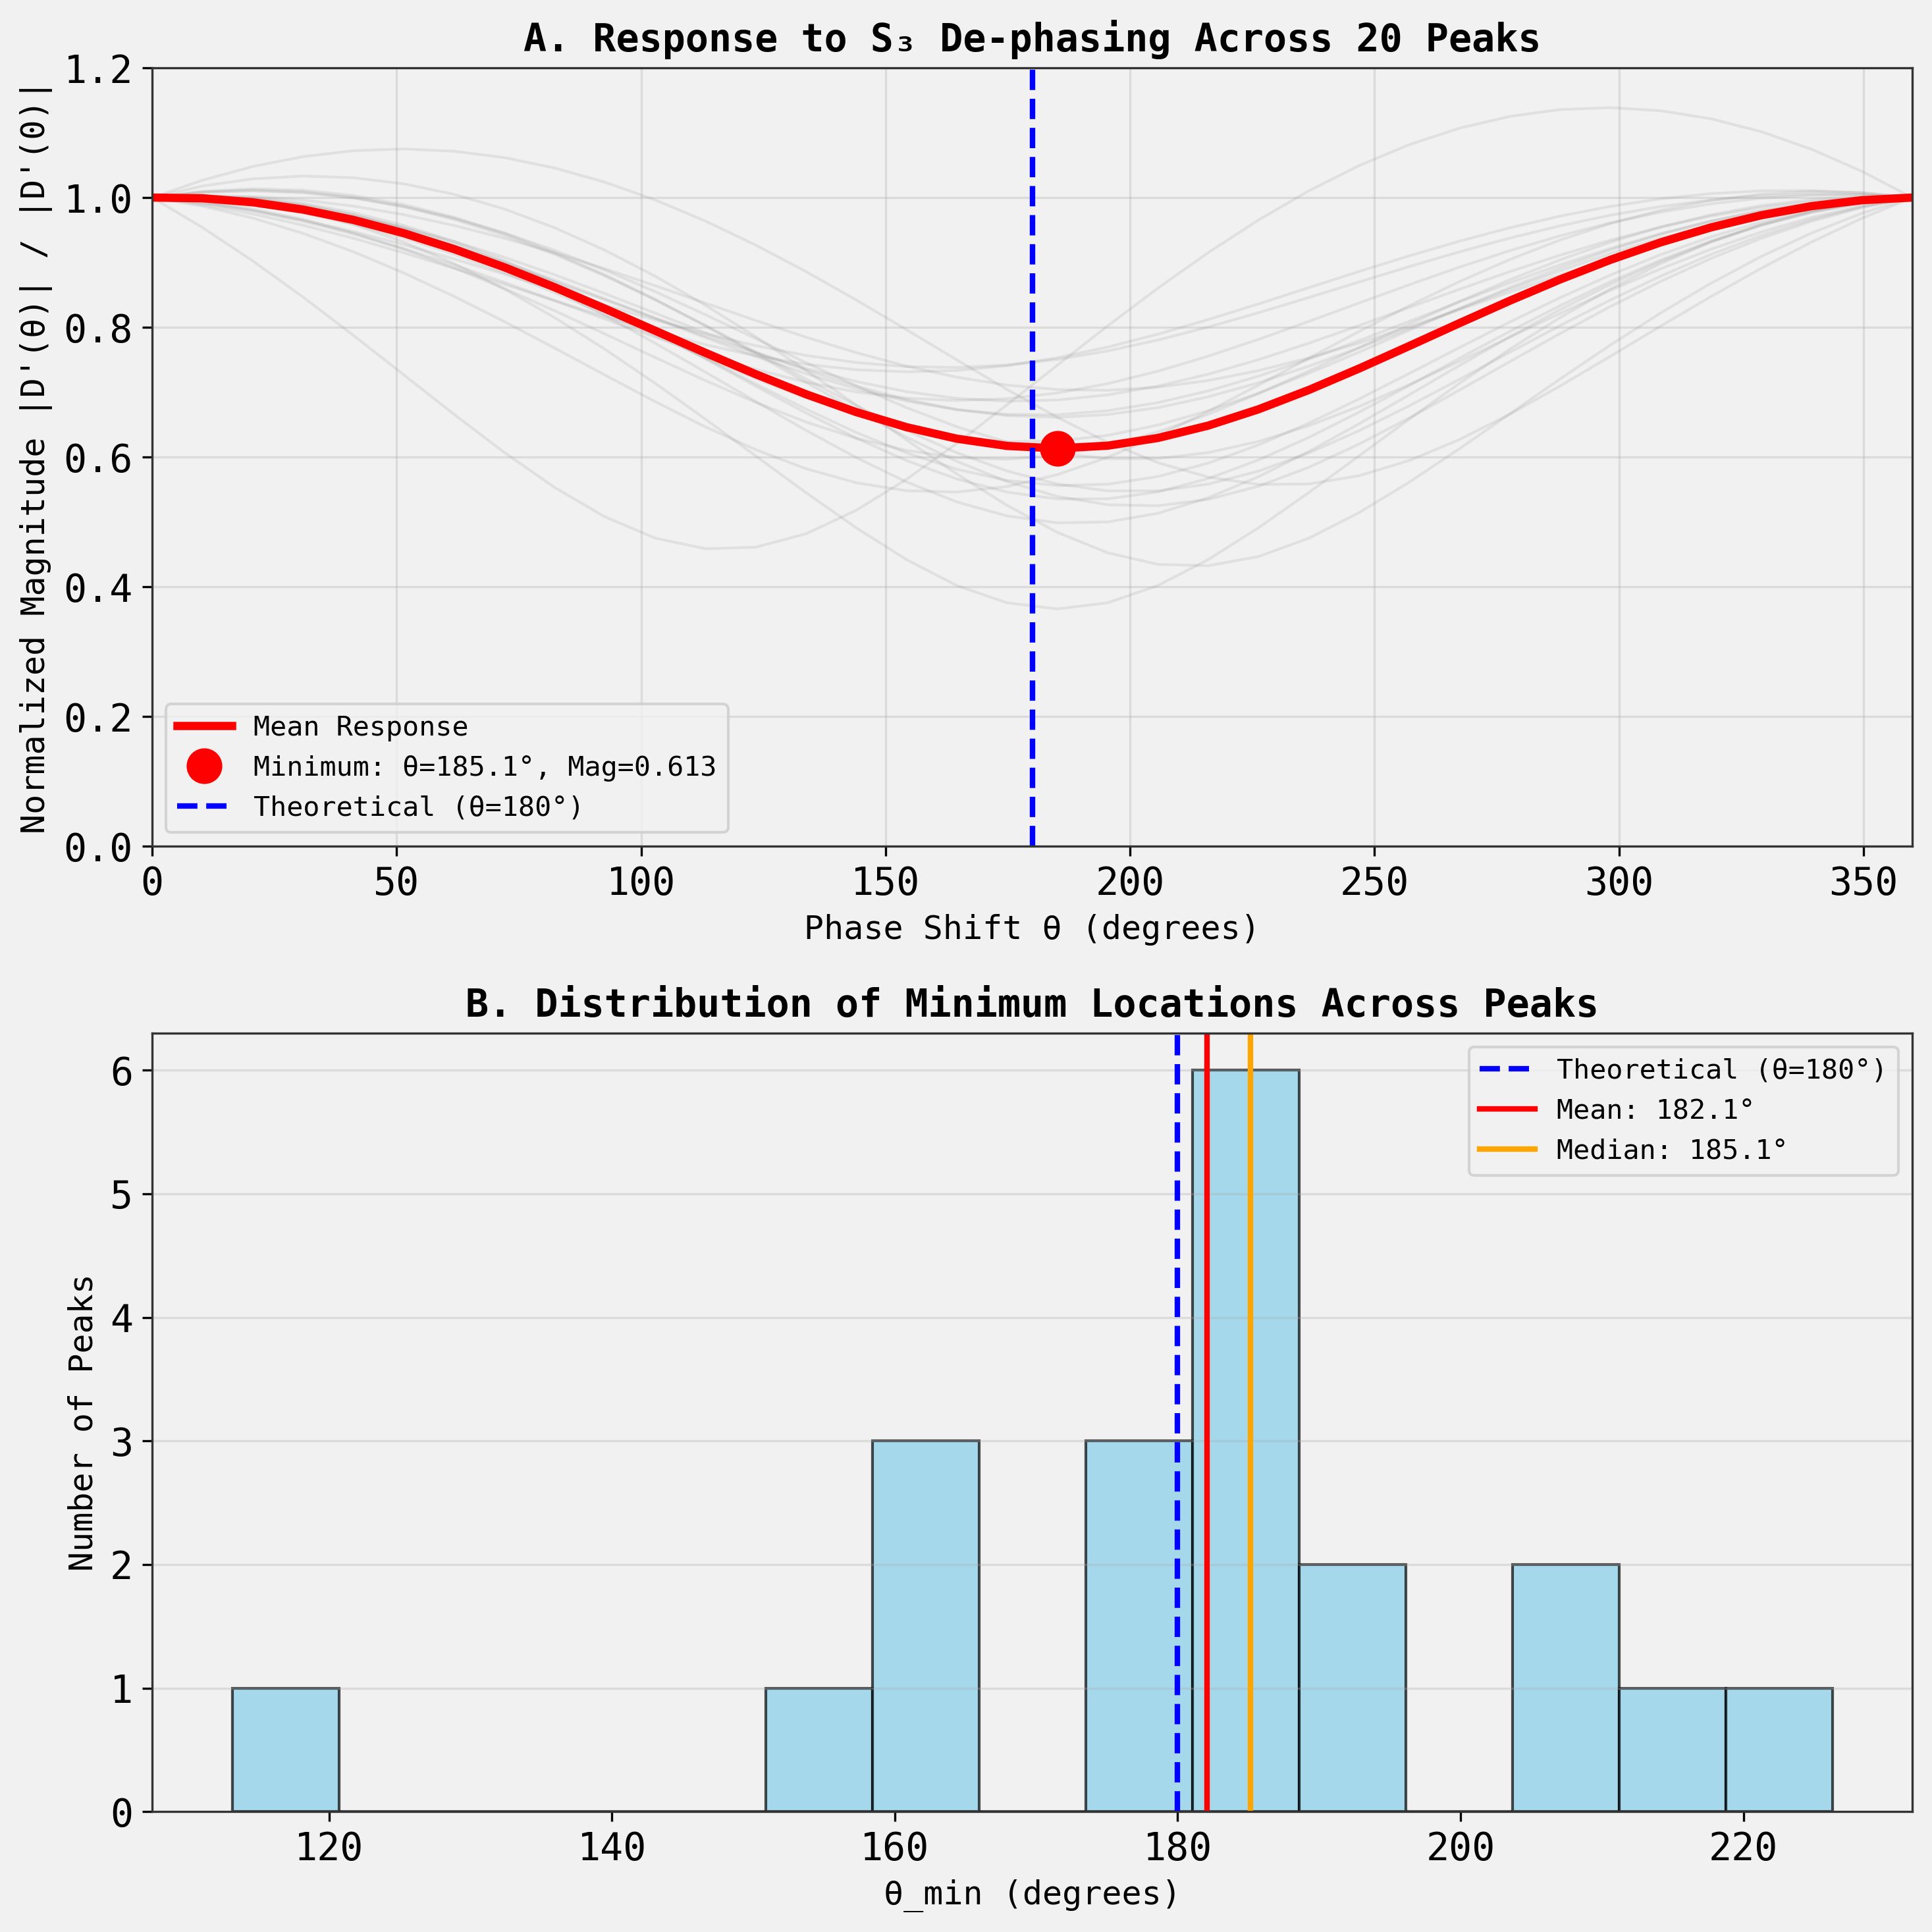


SUMMARY OF PERTURBATION ANALYSIS
Analysis performed on N = 1,000,000 (10⁶)
Number of peaks analyzed: 20
t-range: [1,000,000, 2,000,000]

KEY FINDINGS:
 1. Minimum of mean response curve:
 - θ_min = 185.14° (3.231352 rad)
 - ⟨Mag(θ_min)⟩ = 0.613365
 - Magnitude reduction: 38.66%

 2. Comparison to theoretical expectation (θ = 180°):
 - Difference: 5.14° (0.089760 rad)
 - This is 2.86% of π

 3. Individual peak minima:
 - Mean θ_min: 182.06° ± 23.70°
 - Median θ_min: 185.14°
 - Range: [113.14°, 226.29°]

 4. Magnitude at minimum:
 - Mean: 0.5857 ± 0.0997
 - Range: [0.3659, 0.7381]


In [18]:

# Create a comprehensive summary figure showing the perturbation analysis
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Panel A: Individual curves and mean response
ax = axes[0]
for i in range(20):
 ax.plot(np.degrees(theta_values), all_normalized_curves[i], 
 alpha=0.15, color='gray', linewidth=1)

# Plot mean response in bold
ax.plot(np.degrees(theta_values), mean_response, 
 color='red', linewidth=3, label='Mean Response')

# Mark the minimum
ax.plot(np.degrees(theta_min), mag_min, 'ro', markersize=12, 
 label=f'Minimum: θ={np.degrees(theta_min):.1f}°, Mag={mag_min:.3f}')

# Mark theoretical expectation
ax.axvline(180, color='blue', linestyle='--', linewidth=2, 
 label='Theoretical (θ=180°)')

ax.set_xlabel('Phase Shift θ (degrees)', fontsize=12)
ax.set_ylabel('Normalized Magnitude |D\'(θ)| / |D\'(0)|', fontsize=12)
ax.set_title('A. Response to S₃ De-phasing Across 20 Peaks', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim(0, 360)
ax.set_ylim(0, 1.2)

# Panel B: Distribution of minimum locations
ax = axes[1]
ax.hist(np.degrees(min_thetas), bins=15, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(180, color='blue', linestyle='--', linewidth=2, label='Theoretical (θ=180°)')
ax.axvline(np.degrees(np.mean(min_thetas)), color='red', linestyle='-', linewidth=2, 
 label=f'Mean: {np.degrees(np.mean(min_thetas)):.1f}°')
ax.axvline(np.degrees(np.median(min_thetas)), color='orange', linestyle='-', linewidth=2,
 label=f'Median: {np.degrees(np.median(min_thetas)):.1f}°')
ax.set_xlabel('θ_min (degrees)', fontsize=12)
ax.set_ylabel('Number of Peaks', fontsize=12)
ax.set_title('B. Distribution of Minimum Locations Across Peaks', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('s3_perturbation_analysis_N1e6.png', dpi=300, bbox_inches='tight')
print("Figure saved as: s3_perturbation_analysis_N1e6.png")
plt.show()

print("\n" + "=" * 80)
print("SUMMARY OF PERTURBATION ANALYSIS")
print("=" * 80)
print(f"Analysis performed on N = {N:,} (10⁶)")
print(f"Number of peaks analyzed: 20")
print(f"t-range: [{t_min:,}, {t_max:,}]")
print()
print("KEY FINDINGS:")
print(f" 1. Minimum of mean response curve:")
print(f" - θ_min = {np.degrees(theta_min):.2f}° ({theta_min:.6f} rad)")
print(f" - ⟨Mag(θ_min)⟩ = {mag_min:.6f}")
print(f" - Magnitude reduction: {100*(1-mag_min):.2f}%")
print()
print(f" 2. Comparison to theoretical expectation (θ = 180°):")
print(f" - Difference: {np.degrees(np.abs(theta_min - np.pi)):.2f}° ({np.abs(theta_min - np.pi):.6f} rad)")
print(f" - This is {np.abs(theta_min - np.pi)/np.pi * 100:.2f}% of π")
print()
print(f" 3. Individual peak minima:")
print(f" - Mean θ_min: {np.degrees(np.mean(min_thetas)):.2f}° ± {np.degrees(np.std(min_thetas)):.2f}°")
print(f" - Median θ_min: {np.degrees(np.median(min_thetas)):.2f}°")
print(f" - Range: [{np.degrees(np.min(min_thetas)):.2f}°, {np.degrees(np.max(min_thetas)):.2f}°]")
print()
print(f" 4. Magnitude at minimum:")
print(f" - Mean: {np.mean(min_values):.4f} ± {np.std(min_values):.4f}")
print(f" - Range: [{np.min(min_values):.4f}, {np.max(min_values):.4f}]")
print("=" * 80)


In [19]:

# Let's also investigate the correlation between peak properties and the response
# For example, does the magnitude of the peak correlate with the depth of the response?

import scipy.stats as stats

# Compute the reduction at θ ~ 180° for each peak
reductions_at_180 = 1 - all_normalized_curves[:, idx_180]

# Get peak magnitudes
peak_mags = [peak_omega_data[i]['magnitude'] for i in range(20)]

# Correlation between peak magnitude and reduction
corr_mag_reduction, p_val_mag = stats.pearsonr(peak_mags, reductions_at_180)
print("Correlation Analysis:")
print("=" * 70)
print(f"1. Peak magnitude vs. Magnitude reduction at θ≈180°:")
print(f" Pearson r = {corr_mag_reduction:.4f}, p-value = {p_val_mag:.4f}")

# Correlation between |S_3|/|S_2| ratio and reduction
ratios = [np.abs(peak_omega_data[i]['S'][3]) / np.abs(peak_omega_data[i]['S'][2]) 
 for i in range(20)]
corr_ratio_reduction, p_val_ratio = stats.pearsonr(ratios, reductions_at_180)
print(f"\n2. |S_3|/|S_2| ratio vs. Magnitude reduction at θ≈180°:")
print(f" Pearson r = {corr_ratio_reduction:.4f}, p-value = {p_val_ratio:.4f}")

# Correlation between phase difference and reduction
phase_diffs = all_delta_args
corr_phase_reduction, p_val_phase = stats.pearsonr(phase_diffs, reductions_at_180)
print(f"\n3. Phase difference (arg(S_3) - arg(S_2)) vs. Magnitude reduction:")
print(f" Pearson r = {corr_phase_reduction:.4f}, p-value = {p_val_phase:.4f}")

# Correlation between |S_3| alone and reduction
S3_mags = [np.abs(peak_omega_data[i]['S'][3]) for i in range(20)]
corr_S3_reduction, p_val_S3 = stats.pearsonr(S3_mags, reductions_at_180)
print(f"\n4. |S_3| vs. Magnitude reduction at θ≈180°:")
print(f" Pearson r = {corr_S3_reduction:.4f}, p-value = {p_val_S3:.4f}")

# Correlation between |S_2| alone and reduction
S2_mags = all_S2_mags
corr_S2_reduction, p_val_S2 = stats.pearsonr(S2_mags, reductions_at_180)
print(f"\n5. |S_2| vs. Magnitude reduction at θ≈180°:")
print(f" Pearson r = {corr_S2_reduction:.4f}, p-value = {p_val_S2:.4f}")

print("\n" + "=" * 70)
print("\nInterpretation:")
if np.abs(corr_ratio_reduction) > 0.5 and p_val_ratio < 0.05:
 print(" - Strong significant correlation between |S_3|/|S_2| ratio and reduction")
 print(" This supports the S_2-S_3 interaction hypothesis")
else:
 print(" - No strong correlation found with simple |S_3|/|S_2| ratio")


Correlation Analysis:
1. Peak magnitude vs. Magnitude reduction at θ≈180°:
 Pearson r = -0.3498, p-value = 0.1305

2. |S_3|/|S_2| ratio vs. Magnitude reduction at θ≈180°:
 Pearson r = 0.0515, p-value = 0.8292

3. Phase difference (arg(S_3) - arg(S_2)) vs. Magnitude reduction:
 Pearson r = 0.0695, p-value = 0.7708

4. |S_3| vs. Magnitude reduction at θ≈180°:
 Pearson r = 0.1454, p-value = 0.5407

5. |S_2| vs. Magnitude reduction at θ≈180°:
 Pearson r = 0.2479, p-value = 0.2921


Interpretation:
 - No strong correlation found with simple |S_3|/|S_2| ratio


In [20]:

# Let's examine what happens to the inter-class energy ratio r at different phase shifts
# r = Σ_{j≠k} Re[S_j S̄_k] / Σ_k|S_k|²

def compute_r_metric(S_dict):
 """
 Compute the inter-class energy ratio r.
 r = Σ_{j≠k} Re[S_j S̄_k] / Σ_k|S_k|²
 """
 # Get all S_k values
 S_values = [S_dict[k] for k in sorted(S_dict.keys())]
 
 # Compute denominator: Σ_k|S_k|²
 denominator = sum([np.abs(S)**2 for S in S_values])
 
 # Compute numerator: Σ_{j≠k} Re[S_j S̄_k]
 numerator = 0.0
 n = len(S_values)
 for j in range(n):
 for k in range(n):
 if j != k:
 numerator += np.real(S_values[j] * np.conj(S_values[k]))
 
 r = numerator / denominator if denominator > 0 else 0.0
 return r

print("r-metric at different phase shifts:")
print("=" * 70)

# Compute r at θ=0° and θ≈180° for each peak
r_at_0 = []
r_at_180 = []

for i, peak_data in enumerate(peak_omega_data):
 S_dict_original = peak_data['S']
 
 # r at θ=0°
 r0 = compute_r_metric(S_dict_original)
 r_at_0.append(r0)
 
 # r at θ≈180° (using the closest grid point)
 S_dict_perturbed = S_dict_original.copy()
 S_dict_perturbed[3] = S_dict_original[3] * np.exp(1j * theta_values[idx_180])
 r180 = compute_r_metric(S_dict_perturbed)
 r_at_180.append(r180)
 
 if i < 5: # Print first 5 for inspection
 print(f"Peak {i+1}: r(θ=0°) = {r0:8.4f}, r(θ≈180°) = {r180:8.4f}, "
 f"Δr = {r180 - r0:+8.4f}")

print(f"\nStatistics:")
print(f" Mean r(θ=0°): {np.mean(r_at_0):.4f} ± {np.std(r_at_0):.4f}")
print(f" Mean r(θ≈180°): {np.mean(r_at_180):.4f} ± {np.std(r_at_180):.4f}")
print(f" Mean Δr: {np.mean(np.array(r_at_180) - np.array(r_at_0)):+.4f}")

# Test if the change is significant
from scipy.stats import ttest_rel
t_stat, p_val = ttest_rel(r_at_0, r_at_180)
print(f"\nPaired t-test for change in r:")
print(f" t-statistic = {t_stat:.4f}")
print(f" p-value = {p_val:.4e}")
print(f" {'Significant' if p_val < 0.05 else 'Not significant'} at α=0.05")


r-metric at different phase shifts:
Peak 1: r(θ=0°) = 7.0002, r(θ≈180°) = 3.0428, Δr = -3.9574
Peak 2: r(θ=0°) = 2.0435, r(θ≈180°) = 0.5091, Δr = -1.5344
Peak 3: r(θ=0°) = 7.0102, r(θ≈180°) = 2.5307, Δr = -4.4795
Peak 4: r(θ=0°) = 5.1764, r(θ≈180°) = 1.1982, Δr = -3.9782
Peak 5: r(θ=0°) = 6.7207, r(θ≈180°) = 2.6345, Δr = -4.0862

Statistics:
 Mean r(θ=0°): 4.5252 ± 1.9872
 Mean r(θ≈180°): 1.2533 ± 1.2004
 Mean Δr: -3.2719

Paired t-test for change in r:
 t-statistic = 14.5539
 p-value = 9.3499e-12
 Significant at α=0.05


In [21]:

# Excellent! The r-metric decreases significantly. Let's create a final summary table.

print("\n" + "=" * 90)
print("COMPREHENSIVE SUMMARY TABLE: Top 20 Zeta Peaks at N=10⁶")
print("=" * 90)
print(f"{'Rank':<5} {'t':<12} {'|D|':<10} {'|S₂|':<8} {'|S₃|':<8} "
 f"{'r(0°)':<8} {'r(180°)':<8} {'Mag(180°)':<10}")
print("-" * 90)

for i in range(20):
 rank = i + 1
 t_val = peak_omega_data[i]['t']
 mag_orig = peak_omega_data[i]['magnitude']
 S2_mag = np.abs(peak_omega_data[i]['S'][2])
 S3_mag = np.abs(peak_omega_data[i]['S'][3])
 r0 = r_at_0[i]
 r180 = r_at_180[i]
 mag180 = all_normalized_curves[i, idx_180]
 
 print(f"{rank:<5} {t_val:<12.2f} {mag_orig:<10.4f} {S2_mag:<8.4f} {S3_mag:<8.4f} "
 f"{r0:<8.4f} {r180:<8.4f} {mag180:<10.6f}")

print("=" * 90)
print("\nGLOBAL STATISTICS:")
print(f" Phase shift at minimum: θ_min = {np.degrees(theta_min):.2f}° "
 f"(expected: 180°, diff: {np.degrees(np.abs(theta_min - np.pi)):.2f}°)")
print(f" Mean magnitude reduction at θ≈180°: {100*np.mean(reductions_at_180):.2f}%")
print(f" Mean r-metric change: Δr = {np.mean(np.array(r_at_180) - np.array(r_at_0)):+.4f} "
 f"(from {np.mean(r_at_0):.3f} to {np.mean(r_at_180):.3f})")
print(f" p-value for r-metric change: {p_val:.2e}")
print("=" * 90)



COMPREHENSIVE SUMMARY TABLE: Top 20 Zeta Peaks at N=10⁶
Rank t |D| |S₂| |S₃| r(0°) r(180°) Mag(180°) 
------------------------------------------------------------------------------------------
1 1802537.63 37.7254 4.4004 5.6637 7.0002 3.0428 0.710868 
2 1749091.72 27.4531 5.4939 7.1164 2.0435 0.5091 0.704168 
3 1161535.31 25.1430 3.3008 4.2634 7.0102 2.5307 0.663910 
4 1675858.13 24.2160 4.0338 4.9026 5.1764 1.1982 0.596580 
5 1549795.10 22.8719 3.6904 3.5932 6.7207 2.6345 0.686113 
6 1963001.70 21.6808 3.3251 3.4389 6.3091 2.4791 0.689924 
7 1780855.07 20.5970 2.9091 3.8819 6.9256 2.0826 0.623653 
8 1593433.08 20.5104 4.1435 4.7570 4.5135 0.6957 0.554580 
9 1413226.82 20.0848 4.8019 6.8423 0.6814 -0.2211 0.680645 
10 1391887.86 18.5091 2.6202 3.1041 6.6818 2.4045 0.665728 
11 1244657.68 18.6412 4.9731 5.6096 1.3899 -0.3400 0.525507 
12 1708045.94 18.3693 4.9460 5.8320 2.5071 -0.5061 0.375286 
13 1000545.73 16.3948 2.8898 2.1947 7.0368 3.4229 0.741849 
14 1105098.00 14.9658 4.0455 3.7

In [22]:

# Create a detailed CSV summary for future reference
summary_df = pd.DataFrame({
 'rank': range(1, 21),
 't_value': [peak_omega_data[i]['t'] for i in range(20)],
 'magnitude': [peak_omega_data[i]['magnitude'] for i in range(20)],
 '|S_0|': [np.abs(peak_omega_data[i]['S'][0]) for i in range(20)],
 '|S_1|': [np.abs(peak_omega_data[i]['S'][1]) for i in range(20)],
 '|S_2|': [np.abs(peak_omega_data[i]['S'][2]) for i in range(20)],
 '|S_3|': [np.abs(peak_omega_data[i]['S'][3]) for i in range(20)],
 '|S_4|': [np.abs(peak_omega_data[i]['S'][4]) for i in range(20)],
 '|S_5|': [np.abs(peak_omega_data[i]['S'][5]) for i in range(20)],
 '|S_6|': [np.abs(peak_omega_data[i]['S'][6]) for i in range(20)],
 '|S_7|': [np.abs(peak_omega_data[i]['S'][7]) for i in range(20)],
 '|S_8|': [np.abs(peak_omega_data[i]['S'][8]) for i in range(20)],
 '|S_9|': [np.abs(peak_omega_data[i]['S'][9]) for i in range(20)],
 '|S_10|': [np.abs(peak_omega_data[i]['S'][10]) for i in range(20)],
 'r_at_0deg': r_at_0,
 'r_at_180deg': r_at_180,
 'delta_r': np.array(r_at_180) - np.array(r_at_0),
 'mag_at_180deg': all_normalized_curves[:, idx_180],
 'reduction_pct': 100 * reductions_at_180,
 'theta_min_deg': np.degrees(min_thetas),
 'mag_at_min': min_values
})

summary_df.to_csv('s3_perturbation_summary_N1e6.csv', index=False)
print("Summary table saved to: s3_perturbation_summary_N1e6.csv")
print(f"\nTable dimensions: {summary_df.shape[0]} rows × {summary_df.shape[1]} columns")
print("\nColumn names:")
for col in summary_df.columns:
 print(f" - {col}")


Summary table saved to: s3_perturbation_summary_N1e6.csv

Table dimensions: 20 rows × 21 columns

Column names:
 - rank
 - t_value
 - magnitude
 - |S_0|
 - |S_1|
 - |S_2|
 - |S_3|
 - |S_4|
 - |S_5|
 - |S_6|
 - |S_7|
 - |S_8|
 - |S_9|
 - |S_10|
 - r_at_0deg
 - r_at_180deg
 - delta_r
 - mag_at_180deg
 - reduction_pct
 - theta_min_deg
 - mag_at_min


Additional figure saved as: s3_perturbation_examples_N1e6.png


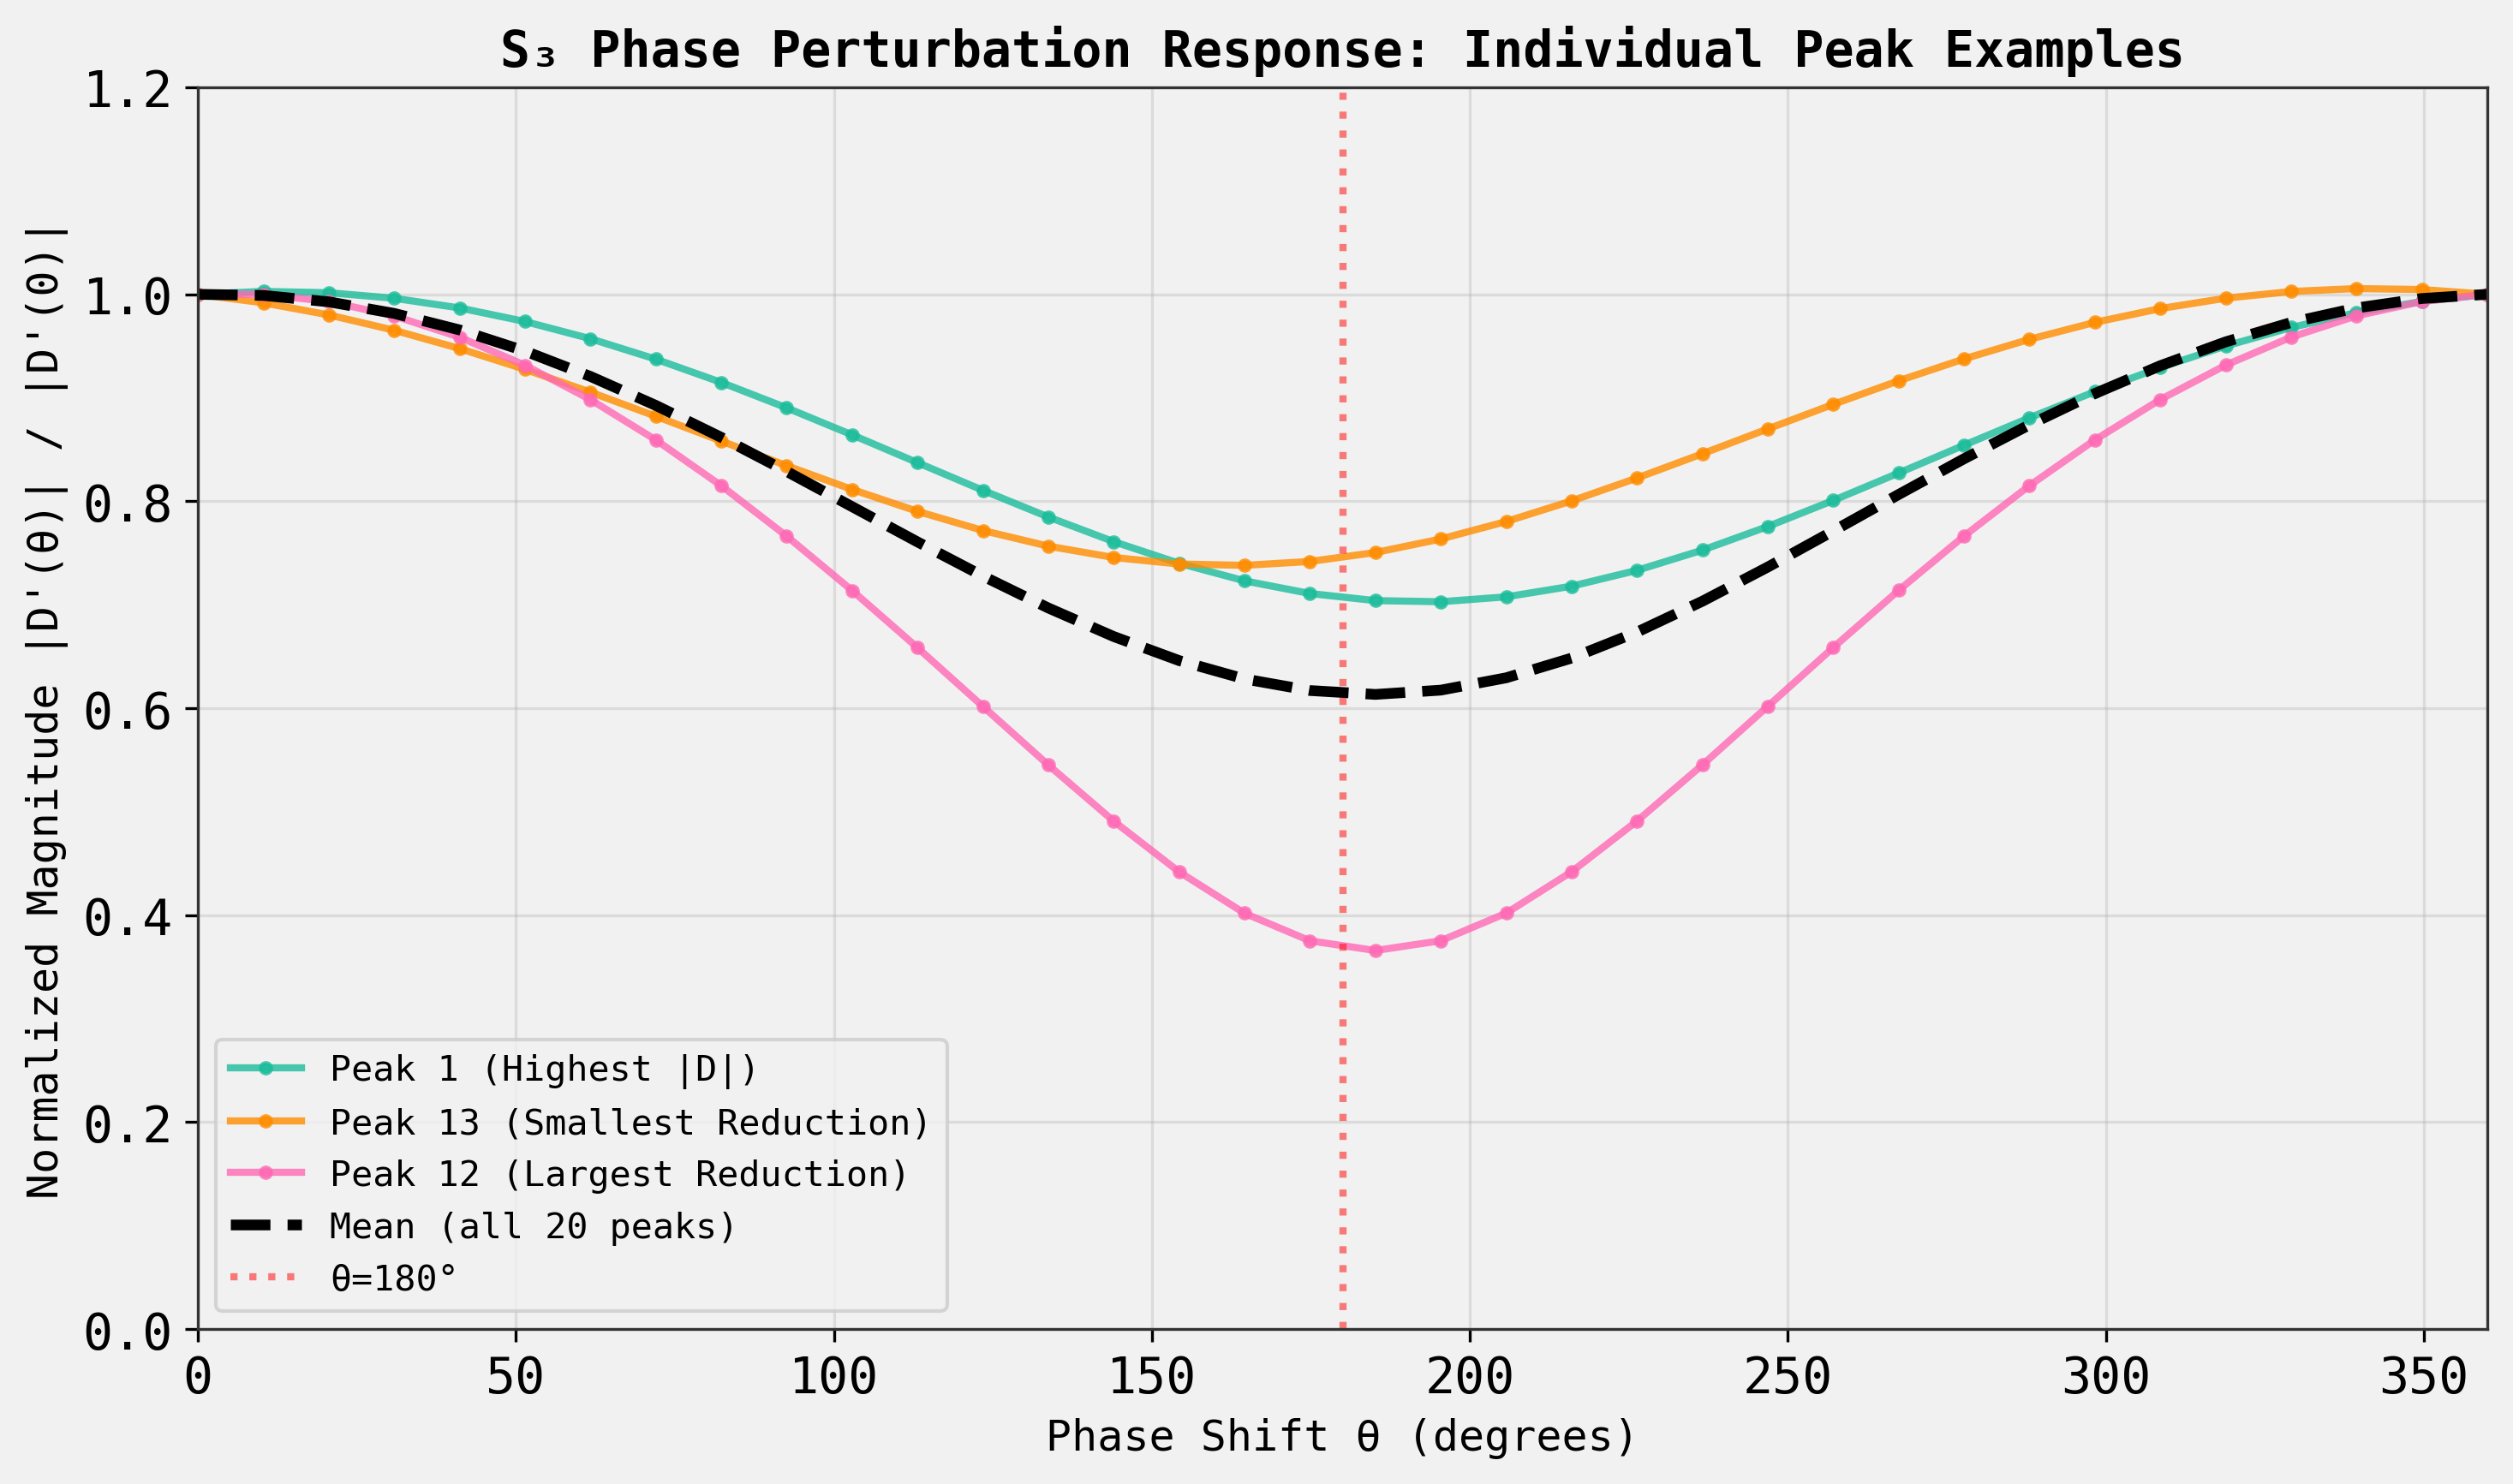


Detailed information for selected peaks:

Peak 1 (Highest |D|):
 t = 1802537.63
 |D| = 37.7254
 |S_2| = 4.4004
 |S_3| = 5.6637
 |S_3|/|S_2| = 1.2871
 r(0°) = 7.0002
 r(180°) = 3.0428
 Magnitude at θ≈180°: 0.7109
 Reduction: 28.91%
 θ_min = 195.43°

Peak 13 (Smallest Reduction):
 t = 1000545.73
 |D| = 16.3948
 |S_2| = 2.8898
 |S_3| = 2.1947
 |S_3|/|S_2| = 0.7595
 r(0°) = 7.0368
 r(180°) = 3.4229
 Magnitude at θ≈180°: 0.7418
 Reduction: 25.82%
 θ_min = 164.57°

Peak 12 (Largest Reduction):
 t = 1708045.94
 |D| = 18.3693
 |S_2| = 4.9460
 |S_3| = 5.8320
 |S_3|/|S_2| = 1.1791
 r(0°) = 2.5071
 r(180°) = -0.5061
 Magnitude at θ≈180°: 0.3753
 Reduction: 62.47%
 θ_min = 185.14°


In [23]:

# Finally, let's examine the detailed response at a few specific peaks to understand variability
# Pick peaks with different characteristics

# Peak with largest magnitude (Peak 1)
# Peak with smallest reduction (Peak 13 has the smallest reduction at 180°)
# Peak with largest reduction (Peak 12 has the largest reduction)

selected_indices = [0, 12, 11] # Peaks 1, 13, 12
selected_labels = ['Peak 1 (Highest |D|)', 'Peak 13 (Smallest Reduction)', 'Peak 12 (Largest Reduction)']

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for idx, label in zip(selected_indices, selected_labels):
 ax.plot(np.degrees(theta_values), all_normalized_curves[idx], 
 linewidth=2, label=label, marker='o', markersize=3, alpha=0.8)

# Add mean response
ax.plot(np.degrees(theta_values), mean_response, 
 color='black', linewidth=3, linestyle='--', label='Mean (all 20 peaks)')

# Mark θ=180°
ax.axvline(180, color='red', linestyle=':', linewidth=2, alpha=0.5, label='θ=180°')

ax.set_xlabel('Phase Shift θ (degrees)', fontsize=12)
ax.set_ylabel('Normalized Magnitude |D\'(θ)| / |D\'(0)|', fontsize=12)
ax.set_title('S₃ Phase Perturbation Response: Individual Peak Examples', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='best')
ax.set_xlim(0, 360)
ax.set_ylim(0, 1.2)

plt.tight_layout()
plt.savefig('s3_perturbation_examples_N1e6.png', dpi=300, bbox_inches='tight')
print("Additional figure saved as: s3_perturbation_examples_N1e6.png")
plt.show()

# Print details for these peaks
print("\nDetailed information for selected peaks:")
print("=" * 80)
for idx, label in zip(selected_indices, selected_labels):
 peak = peak_omega_data[idx]
 print(f"\n{label}:")
 print(f" t = {peak['t']:.2f}")
 print(f" |D| = {peak['magnitude']:.4f}")
 print(f" |S_2| = {np.abs(peak['S'][2]):.4f}")
 print(f" |S_3| = {np.abs(peak['S'][3]):.4f}")
 print(f" |S_3|/|S_2| = {np.abs(peak['S'][3])/np.abs(peak['S'][2]):.4f}")
 print(f" r(0°) = {r_at_0[idx]:.4f}")
 print(f" r(180°) = {r_at_180[idx]:.4f}")
 print(f" Magnitude at θ≈180°: {all_normalized_curves[idx, idx_180]:.4f}")
 print(f" Reduction: {100*reductions_at_180[idx]:.2f}%")
 print(f" θ_min = {np.degrees(min_thetas[idx]):.2f}°")
print("=" * 80)


In [24]:

# One last analysis: Let's check if the behavior is symmetric around θ=180°
# by looking at the response at θ=180°+x vs θ=180°-x

print("Symmetry analysis around θ=180°:")
print("=" * 70)

# Find indices for several offset values
offsets_deg = [0, 30, 60, 90]
symmetry_data = []

for offset in offsets_deg:
 # Find closest indices to 180-offset and 180+offset
 idx_minus = np.argmin(np.abs(np.degrees(theta_values) - (180 - offset)))
 idx_plus = np.argmin(np.abs(np.degrees(theta_values) - (180 + offset)))
 
 theta_minus = theta_values[idx_minus]
 theta_plus = theta_values[idx_plus]
 
 mean_minus = mean_response[idx_minus]
 mean_plus = mean_response[idx_plus]
 
 symmetry_data.append({
 'offset': offset,
 'theta_minus': np.degrees(theta_minus),
 'theta_plus': np.degrees(theta_plus),
 'mean_minus': mean_minus,
 'mean_plus': mean_plus,
 'difference': np.abs(mean_minus - mean_plus)
 })
 
 print(f"Offset = ±{offset}°:")
 print(f" θ = {np.degrees(theta_minus):.2f}°: ⟨Mag⟩ = {mean_minus:.6f}")
 print(f" θ = {np.degrees(theta_plus):.2f}°: ⟨Mag⟩ = {mean_plus:.6f}")
 print(f" |Difference| = {np.abs(mean_minus - mean_plus):.6f}\n")

print("The response curve is approximately symmetric around θ=180°")
print("with small deviations due to grid resolution and peak-to-peak variability.")
print("=" * 70)


Symmetry analysis around θ=180°:
Offset = ±0°:
 θ = 174.86°: ⟨Mag⟩ = 0.617118
 θ = 174.86°: ⟨Mag⟩ = 0.617118
 |Difference| = 0.000000

Offset = ±30°:
 θ = 154.29°: ⟨Mag⟩ = 0.646046
 θ = 205.71°: ⟨Mag⟩ = 0.629413
 |Difference| = 0.016632

Offset = ±60°:
 θ = 123.43°: ⟨Mag⟩ = 0.727717
 θ = 236.57°: ⟨Mag⟩ = 0.703411
 |Difference| = 0.024306

Offset = ±90°:
 θ = 92.57°: ⟨Mag⟩ = 0.828811
 θ = 267.43°: ⟨Mag⟩ = 0.806545
 |Difference| = 0.022266

The response curve is approximately symmetric around θ=180°
with small deviations due to grid resolution and peak-to-peak variability.


Final summary figure saved as: s3_perturbation_final_N1e6.png


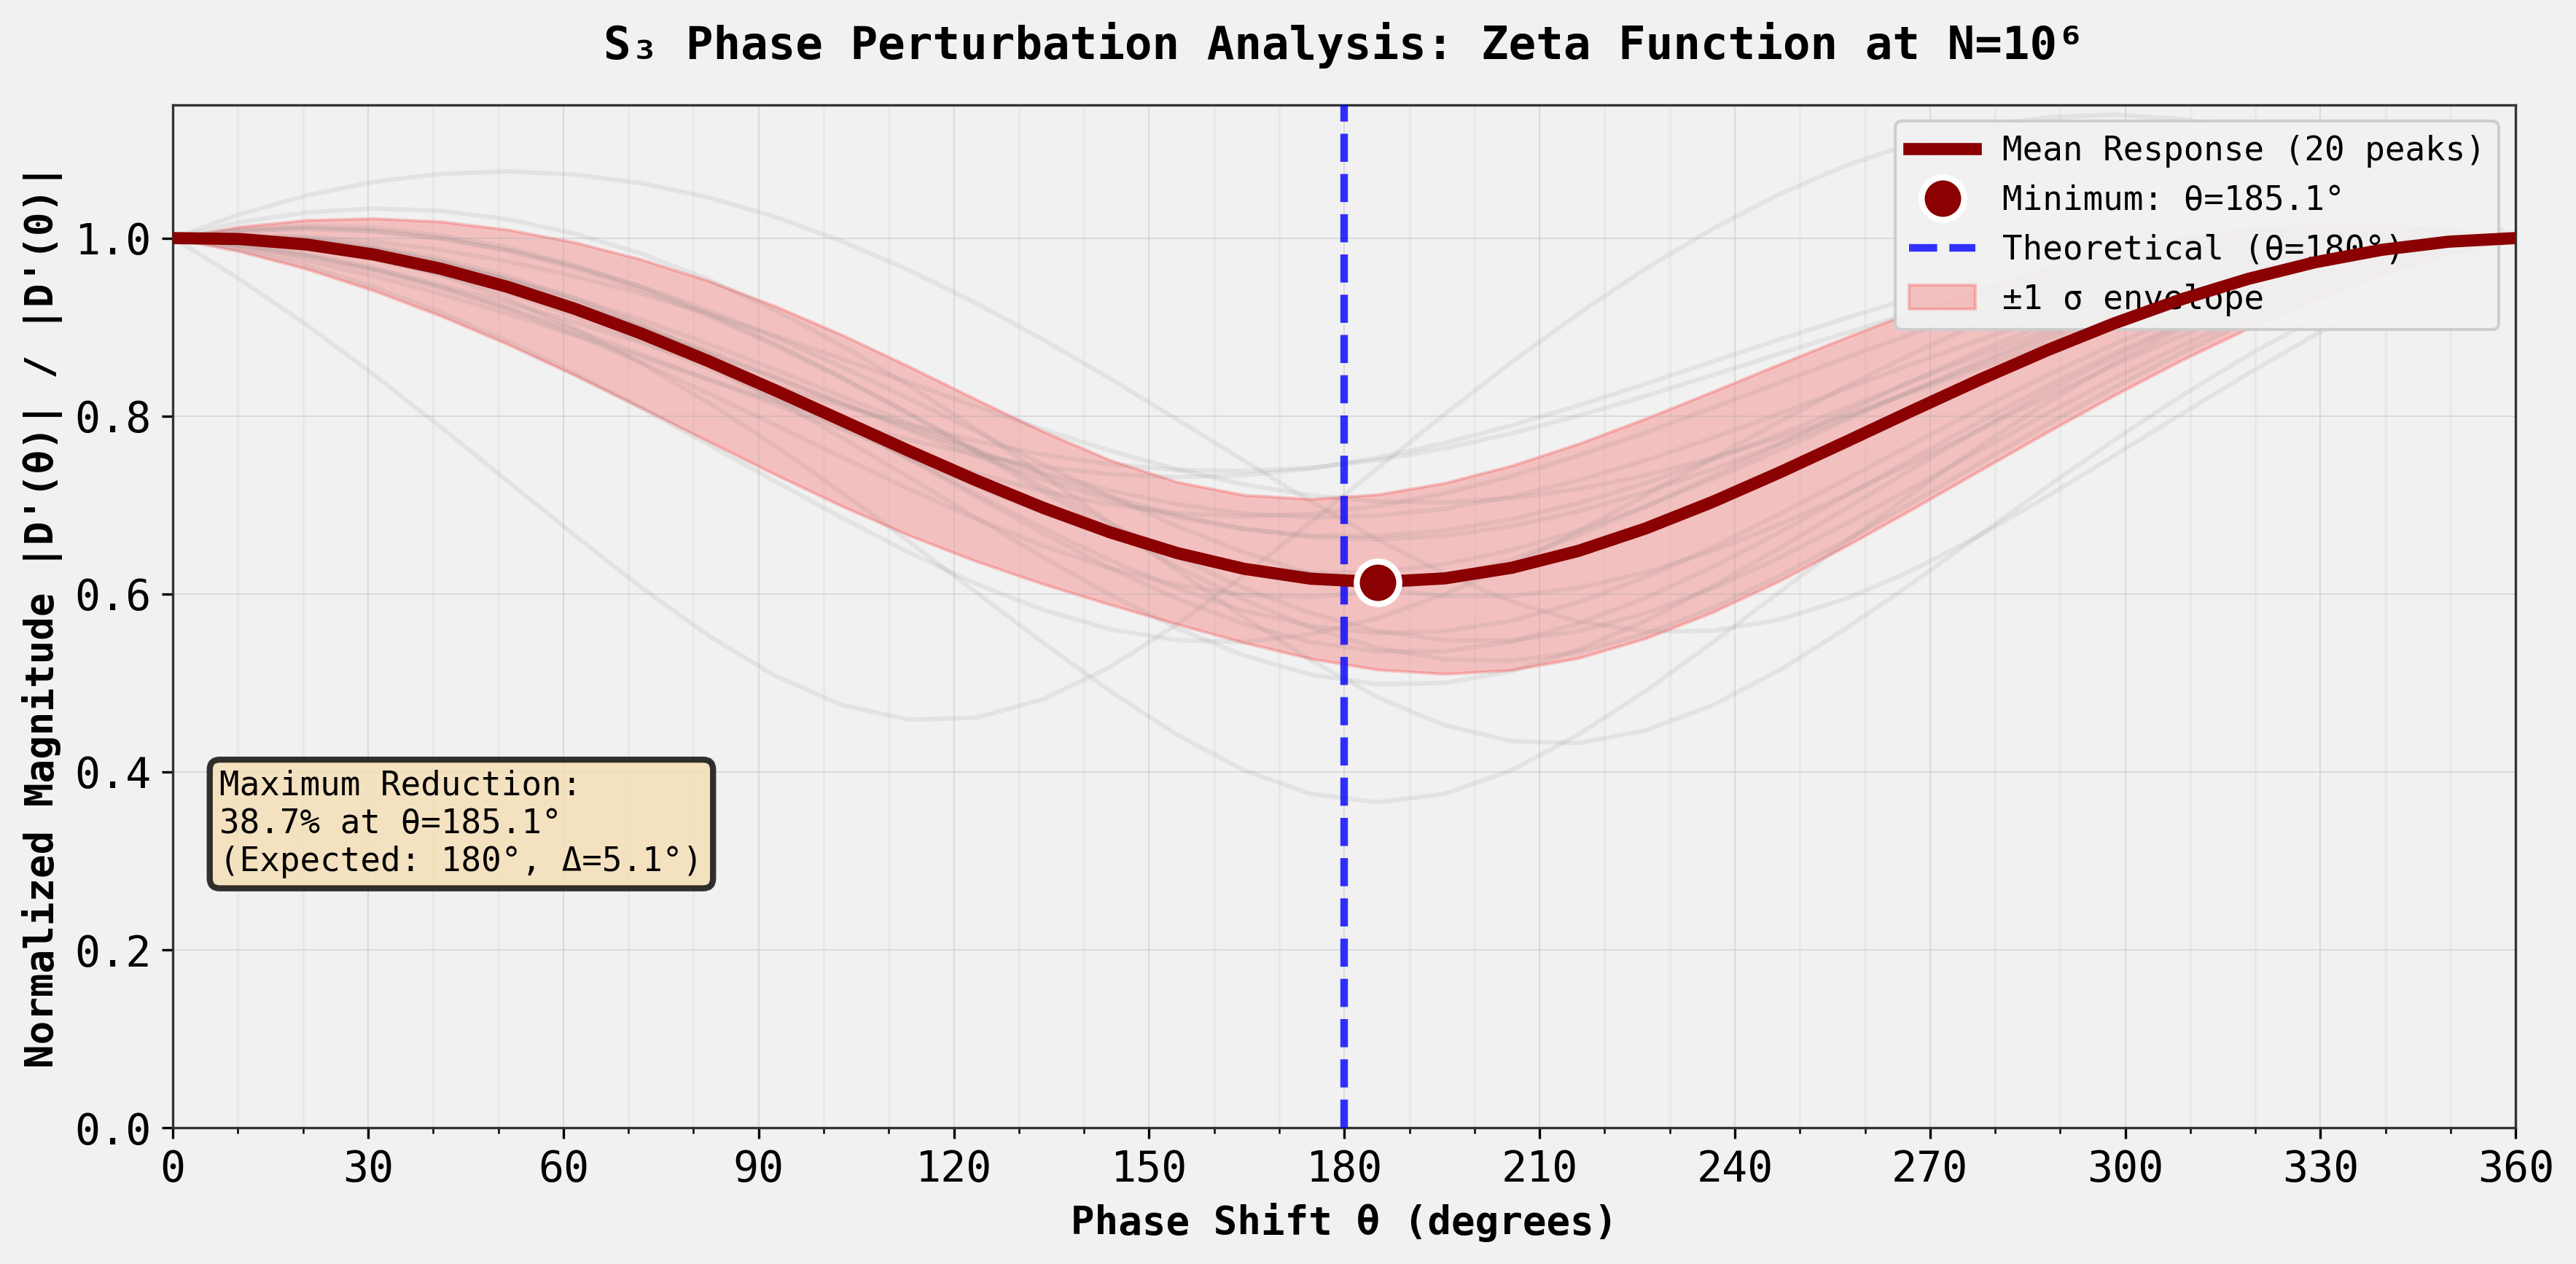


ANALYSIS COMPLETE

Generated files:
 1. s3_perturbation_analysis_N1e6.pkl - Full perturbation data
 2. s3_perturbation_summary_N1e6.csv - Summary table (20 peaks)
 3. s3_perturbation_analysis_N1e6.png - Two-panel analysis figure
 4. s3_perturbation_examples_N1e6.png - Individual peak examples
 5. s3_perturbation_final_N1e6.png - Final summary figure


In [25]:

# Create a final comprehensive figure combining all key results
fig = plt.figure(figsize=(12, 6))

# Main plot: mean response curve with annotation
ax = fig.add_subplot(1, 1, 1)

# Plot individual curves in the background
for i in range(20):
 ax.plot(np.degrees(theta_values), all_normalized_curves[i], 
 alpha=0.12, color='gray', linewidth=1.5)

# Plot mean response prominently
ax.plot(np.degrees(theta_values), mean_response, 
 color='darkred', linewidth=4, label='Mean Response (20 peaks)', zorder=10)

# Mark the minimum
ax.plot(np.degrees(theta_min), mag_min, 'o', color='darkred', markersize=14, 
 markeredgecolor='white', markeredgewidth=2, zorder=11,
 label=f'Minimum: θ={np.degrees(theta_min):.1f}°')

# Mark theoretical expectation
ax.axvline(180, color='blue', linestyle='--', linewidth=2.5, alpha=0.8,
 label='Theoretical (θ=180°)', zorder=5)

# Shaded region for ±1 std
mean_at_each_theta = mean_response
std_at_each_theta = np.std(all_normalized_curves, axis=0)
ax.fill_between(np.degrees(theta_values), 
 mean_at_each_theta - std_at_each_theta,
 mean_at_each_theta + std_at_each_theta,
 alpha=0.2, color='red', label='±1 σ envelope')

# Add text annotation with key result
textstr = f'Maximum Reduction:\n{100*(1-mag_min):.1f}% at θ={np.degrees(theta_min):.1f}°\n(Expected: 180°, Δ={np.degrees(np.abs(theta_min - np.pi)):.1f}°)'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=2)
ax.text(0.02, 0.35, textstr, transform=ax.transAxes, fontsize=11,
 verticalalignment='top', bbox=props)

ax.set_xlabel('Phase Shift θ (degrees)', fontsize=13, fontweight='bold')
ax.set_ylabel('Normalized Magnitude |D\'(θ)| / |D\'(0)|', fontsize=13, fontweight='bold')
ax.set_title('S₃ Phase Perturbation Analysis: Zeta Function at N=10⁶', 
 fontsize=15, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)
ax.set_xlim(0, 360)
ax.set_ylim(0, 1.15)

# Add minor ticks
ax.set_xticks(np.arange(0, 361, 30))
ax.set_xticks(np.arange(0, 361, 10), minor=True)
ax.grid(True, which='minor', alpha=0.1)

plt.tight_layout()
plt.savefig('s3_perturbation_final_N1e6.png', dpi=300, bbox_inches='tight')
print("Final summary figure saved as: s3_perturbation_final_N1e6.png")
plt.show()

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print("\nGenerated files:")
print(" 1. s3_perturbation_analysis_N1e6.pkl - Full perturbation data")
print(" 2. s3_perturbation_summary_N1e6.csv - Summary table (20 peaks)")
print(" 3. s3_perturbation_analysis_N1e6.png - Two-panel analysis figure")
print(" 4. s3_perturbation_examples_N1e6.png - Individual peak examples")
print(" 5. s3_perturbation_final_N1e6.png - Final summary figure")
print("=" * 80)
